In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [47]:
# Import Train, Test

import pickle

with open("allDataset.pkl", "rb") as f:
  allDataset = pickle.load(f)

with open("x_train_cnn.pkl", "rb") as f:
  x_train_cnn = pickle.load(f)

with open("y_train_cnn.pkl", "rb") as f:
  y_train_cnn = pickle.load(f)

with open("x_test_cnn.pkl", "rb") as f:
  x_test_cnn = pickle.load(f)

with open("y_test_cnn.pkl", "rb") as f:
  y_test_cnn = pickle.load(f)

with open("x_train_ann.pkl", "rb") as f:
  x_train_ann = pickle.load(f)

with open("y_train_ann.pkl", "rb") as f:
  y_train_ann = pickle.load(f)

with open("x_test_ann.pkl", "rb") as f:
  x_test_ann = pickle.load(f)

with open("y_test_ann.pkl", "rb") as f:
  y_test_ann = pickle.load(f)

In [48]:
# Final Classification

import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Dropout

cnn_model = tf.keras.models.load_model("cnn_model.keras")
ann_model = tf.keras.models.load_model("ann_model.keras")

cnn_predictions_train = cnn_model.predict(x_train_cnn)
cnn_predictions_test = cnn_model.predict(x_test_cnn)

ann_predictions_train = ann_model.predict(x_train_ann)
ann_predictions_test = ann_model.predict(x_test_ann)

final_train = np.concatenate([cnn_predictions_train, ann_predictions_train], axis = 1)
final_test = np.concatenate([cnn_predictions_test, ann_predictions_test], axis = 1)

final = Sequential()

151/151 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [49]:
final.add(Dense(units = 128, input_shape = (final_train.shape[1], ), activation = "relu"))
final.add(Dense(units = 64, activation = "relu"))
final.add(Dropout(0.3))
final.add(Dense(units = 32, activation = "relu"))
final.add(Dropout(0.3))
final.add(Dense(units = 6, activation = "softmax"))

d:\2. My Learning\03. Data Science\02. Learn\02. NTI-Huawei\16. Final Project\Project\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
final.compile(optimizer = "adam", loss = "categorical_crossentropy", metrics = ["accuracy"])
hist = final.fit(final_train, y_train_ann, epochs = 50, validation_split = 0.2, batch_size = 128)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6461 - loss: 1.2642 - val_accuracy: 0.8394 - val_loss: 0.6673
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8756 - loss: 0.4764 - val_accuracy: 0.9264 - val_loss: 0.3368
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9500 - loss: 0.2293 - val_accuracy: 0.9420 - val_loss: 0.2738
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9712 - loss: 0.1501 - val_accuracy: 0.9451 - val_loss: 0.2667
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9798 - loss: 0.1192 - val_accuracy: 0.9440 - val_loss: 0.2695
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9767 - loss: 0.1041 - val_accuracy: 0.9461 - val_loss: 0.2876
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9829 - loss: 0.0865 - val_accuracy: 0.9503 - val_loss: 0.2774
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9821 - loss: 0.0842 - val_accuracy: 0.9482 - val_loss

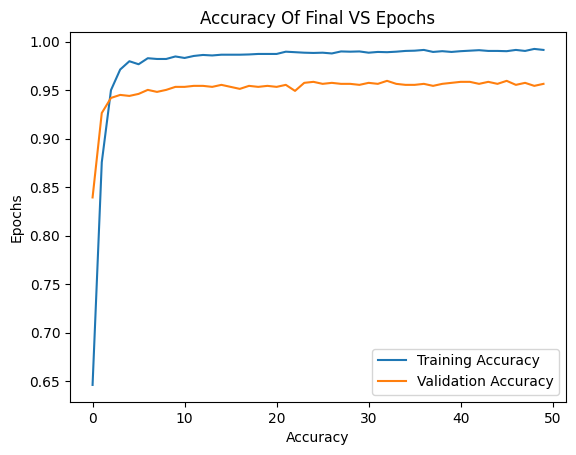

In [51]:
# Accuracy Visualization

plt.plot(hist.history["accuracy"], label = "Training Accuracy")
plt.plot(hist.history["val_accuracy"], label = "Validation Accuracy")

plt.title("Accuracy Of Final VS Epochs")
plt.xlabel("Accuracy")
plt.ylabel("Epochs")

plt.legend()
plt.show()

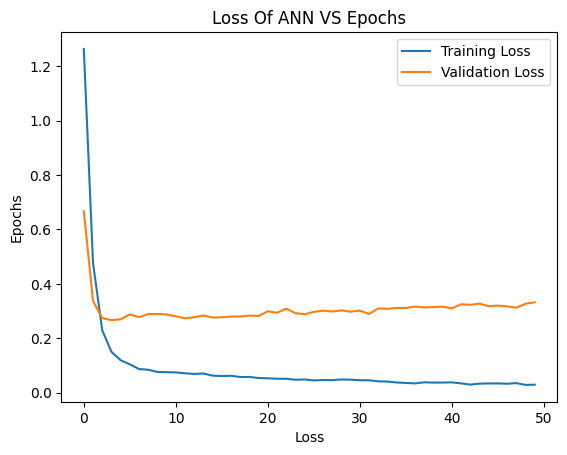

In [52]:
# Loss Visualization

plt.plot(hist.history["loss"], label = "Training Loss")
plt.plot(hist.history["val_loss"], label = "Validation Loss")

plt.title("Loss Of ANN VS Epochs")
plt.xlabel("Loss")
plt.ylabel("Epochs")

plt.legend()
plt.show()

In [53]:
# Evaluate The model

model_loss, model_accuracy = final.evaluate(final_test, y_test_ann)

print(f"Model Loss {model_loss}")
print(f"Model Accuracy {model_accuracy}")

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9541 - loss: 0.3883
Model Loss 0.3882801830768585
Model Accuracy 0.9540840983390808


In [54]:
# Save Model

final.save("final_model.keras")